# Normalization idea and non-negative f

In this notebook, we will attempt to understand when f becomes negative, given an H and g.

The idea is that for some values of g, the optimal solution requires a value in f to become negative.

We will start with a toy example (two dimensional f and g), plot, compute the optimal solution by hand. And attempt to generalize the condition in g for which f becomes negative for any element.

This will help us generalize and come up with a heuristic for normalizing our actual gene expression and chromatin data, to keep f as a positive valued solution. If we are able to do this, we will still need to be mindful of how the normalization will affect downstream analyses.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Take the partial derivative d/dx

	1.25x + 0.75y = 4.95

Take the partial derivative d/dy

	0.75x + 1.25y = 2.85

Thus, the solution to the optimization is:

	x = 4.05
	y = -0.15


Text(0.5, 1.0, 'Example of negative solution')

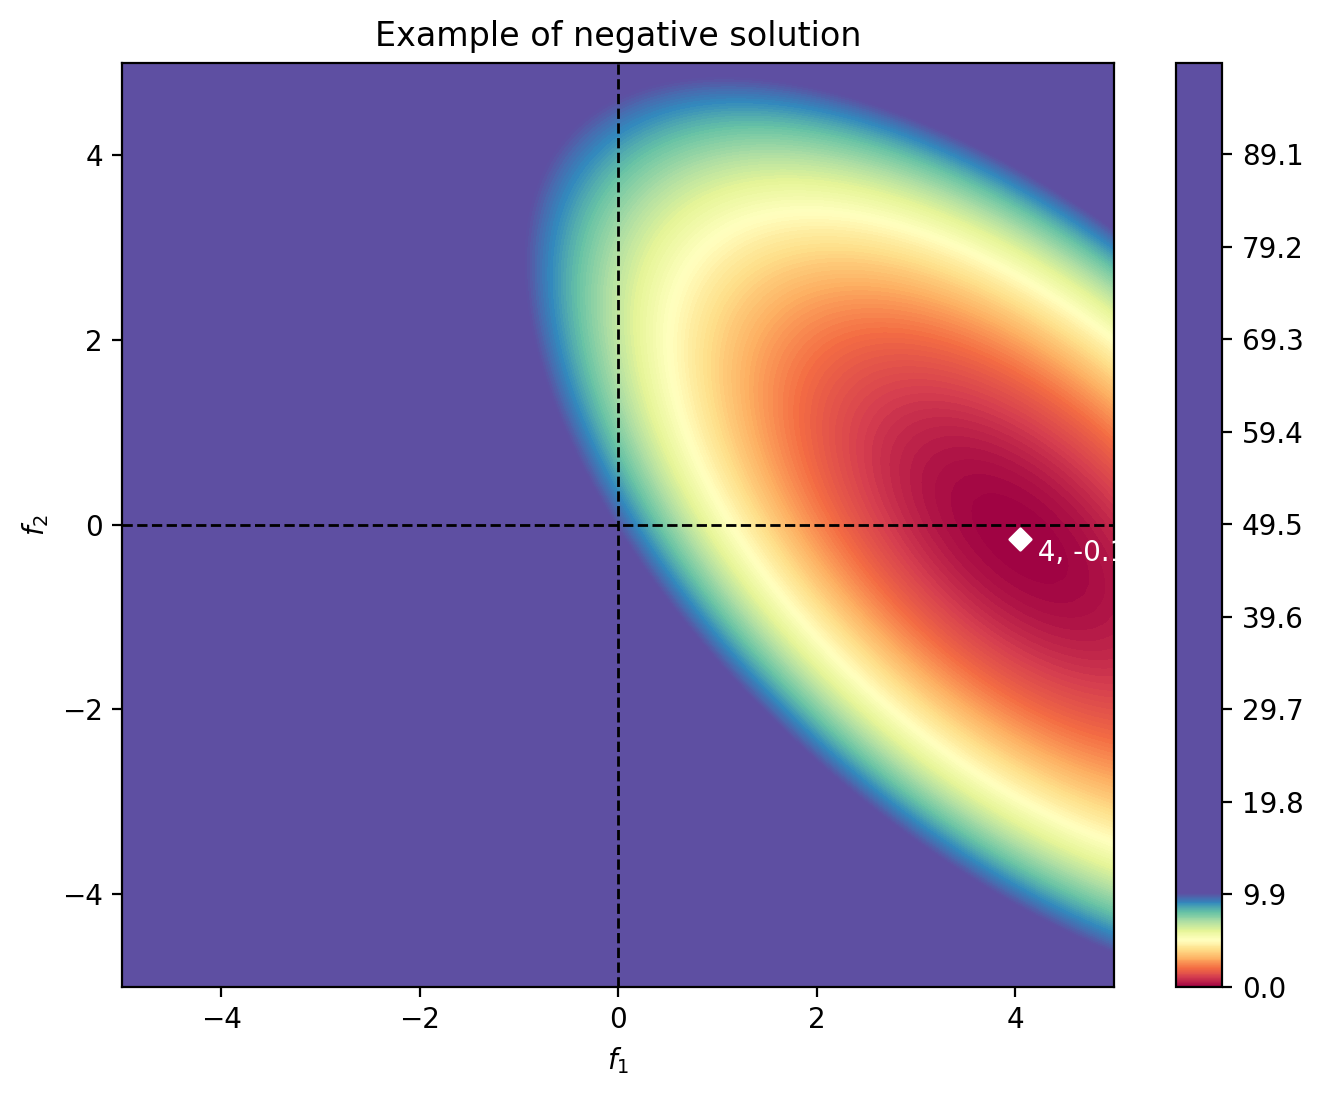

In [223]:
from src.toy_example_deconv import ToyDeconv

toy = ToyDeconv(g1=0.9, g2=3)
toy.find_solution(log=True)
toy.plot_optimization_and_solution()
plt.title("Example of negative solution")

Locator attempting to generate 1001 ticks ([0.0, ..., 100.0]), which exceeds Locator.MAXTICKS (1000).


Text(0.5, 1.0, 'Example of non-negative solution')

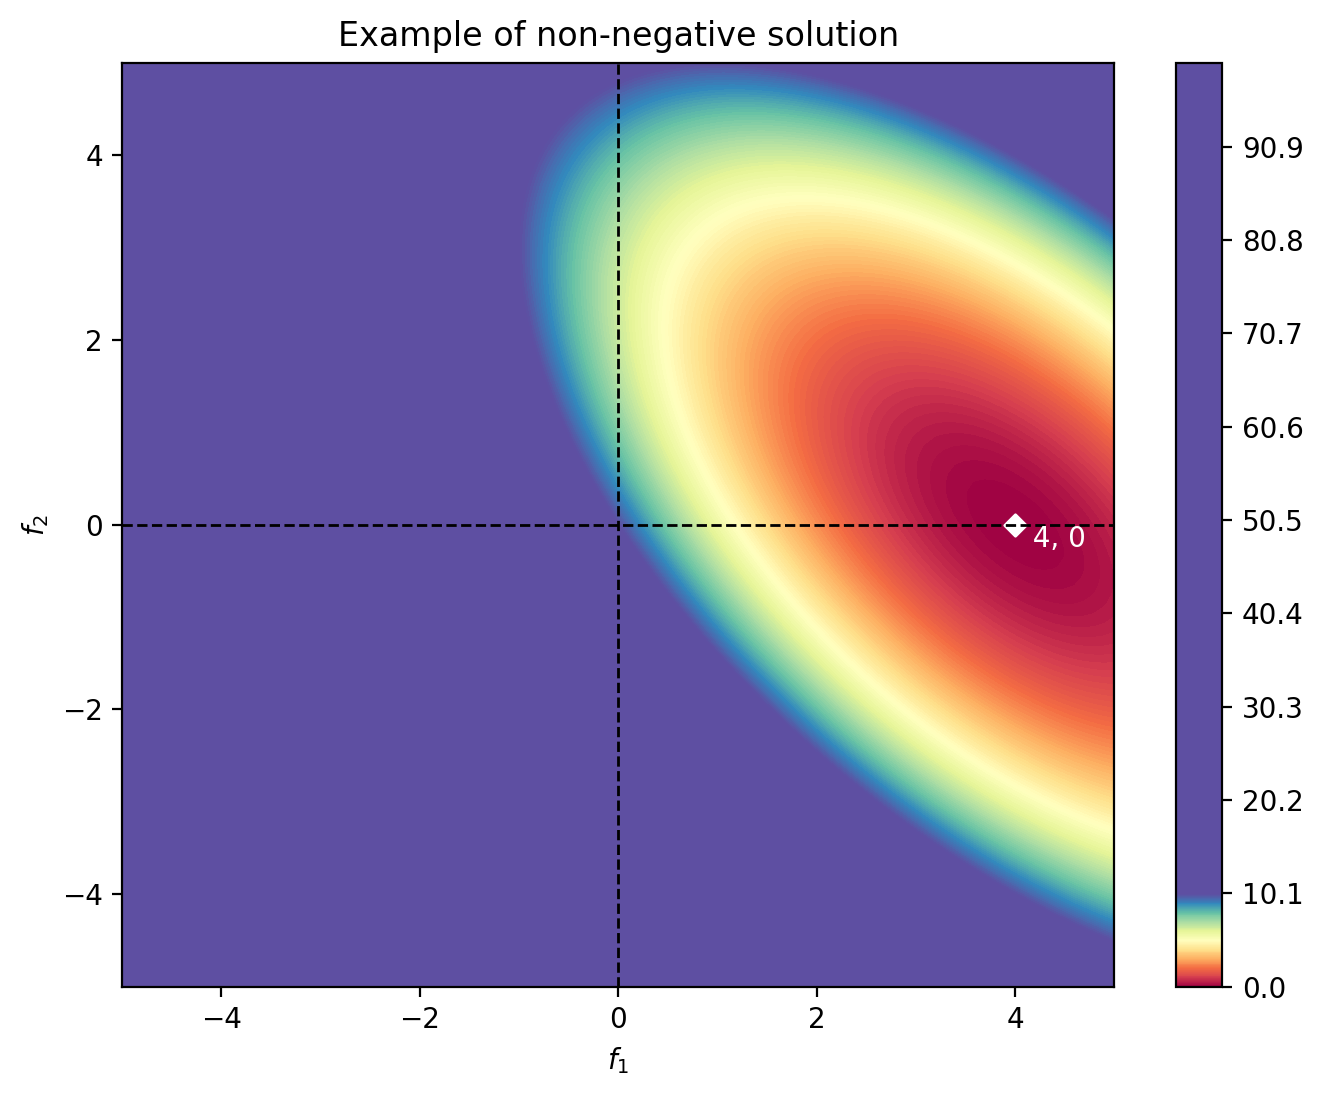

In [224]:
toy = ToyDeconv(g1=1, g2=3)
toy.find_solution()
toy.plot_optimization_and_solution()
plt.title("Example of non-negative solution")

In [244]:
from src.config import load_yl_replicate1_rg1_TPM_config
from src.model import Model

config = load_yl_replicate1_rg1_TPM_config()
model = Model(config, 'RNR1', 0.0)


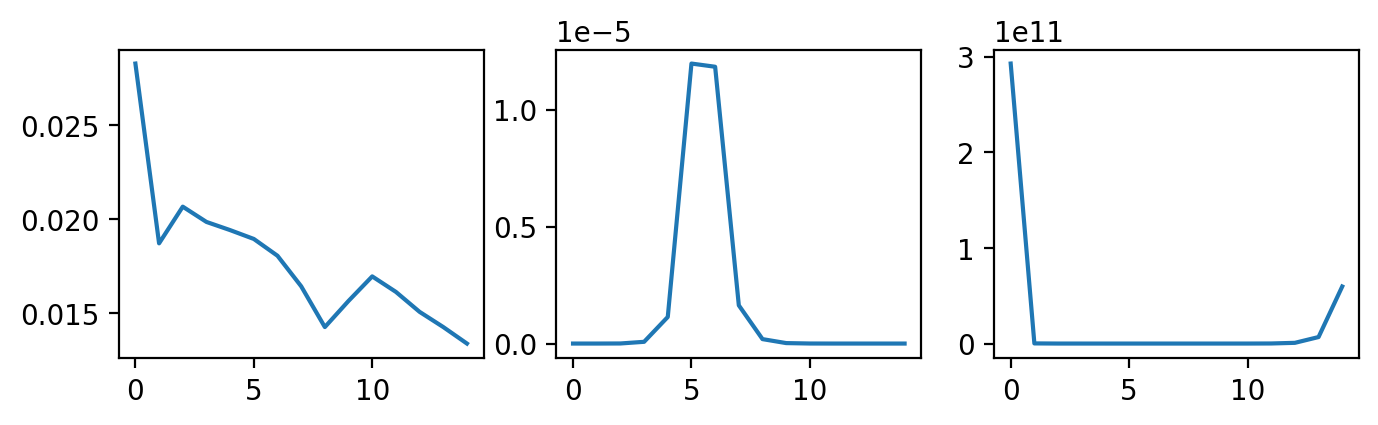

In [245]:
plt.figure(figsize=(8, 2))
plt.subplot(1, 3, 1)
plt.plot(model.H.max(axis=1))
plt.subplot(1, 3, 2)
plt.plot(model.H.min(axis=1))
plt.subplot(1, 3, 3)
plt.plot(model.H.max(axis=1) / model.H.min(axis=1))


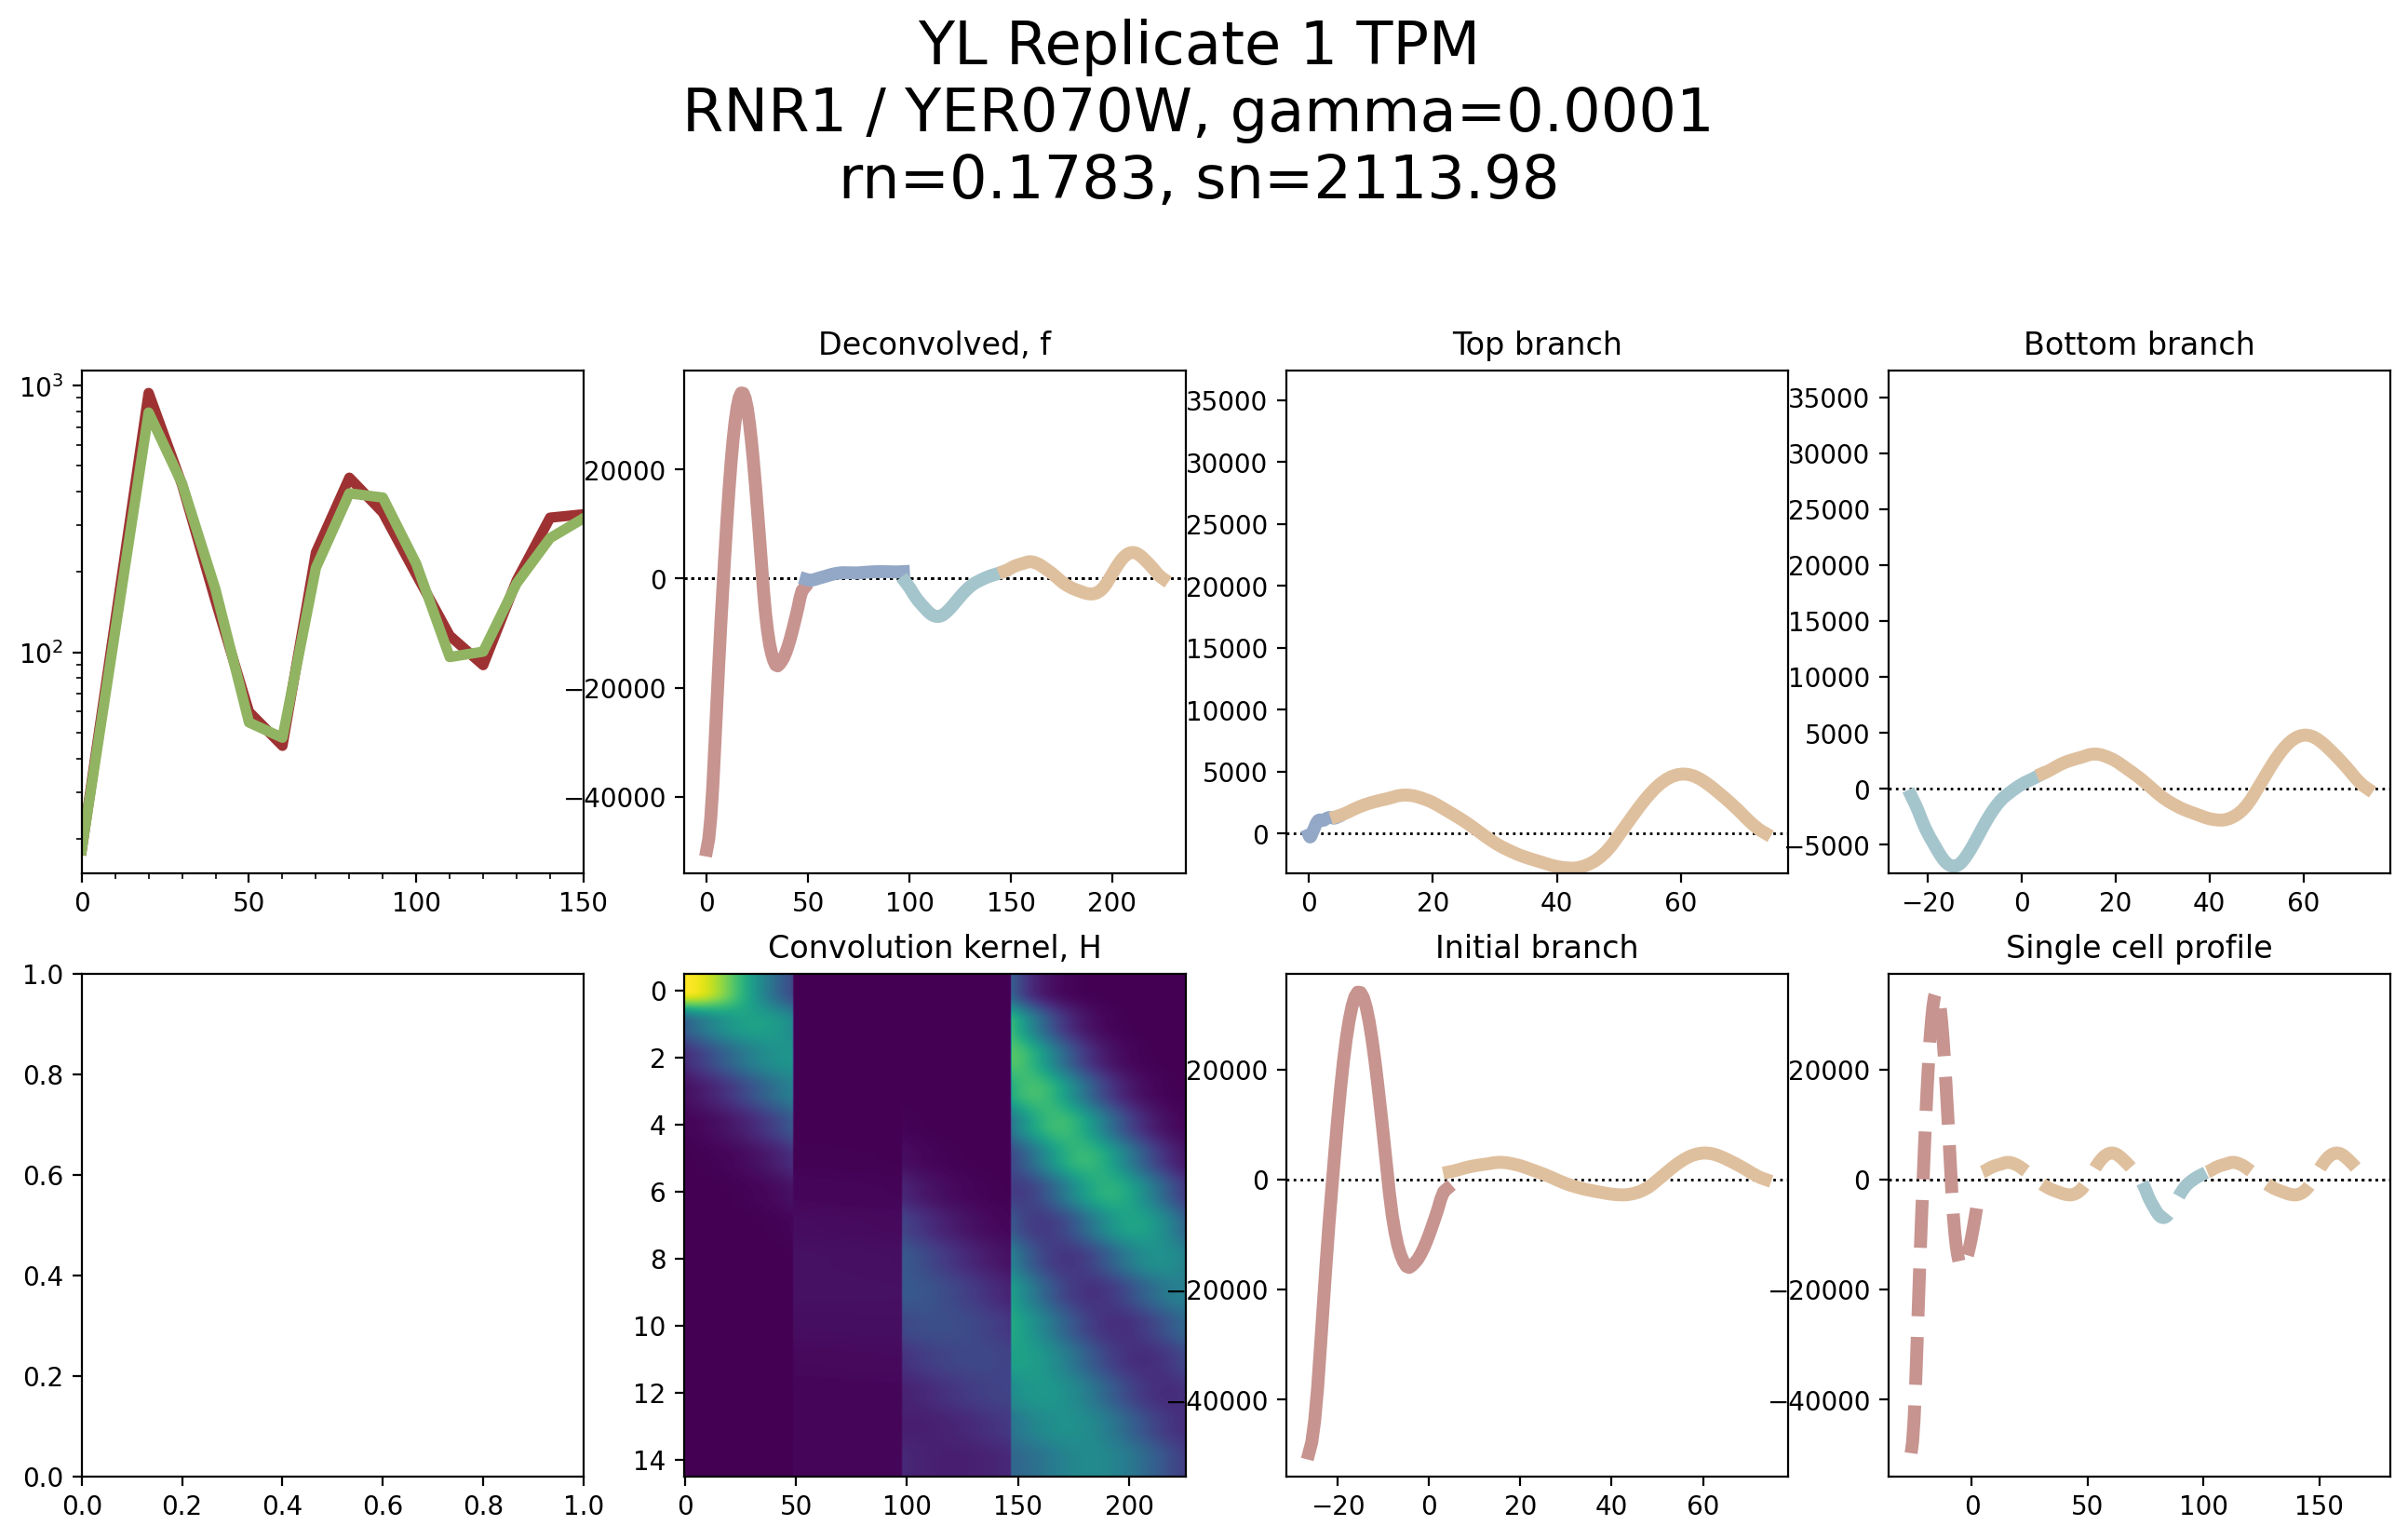

In [257]:
model = Model(config, 'RNR1', 0.0001)

model.deconvolve(enforce_non_negative=False)
model.plot_deconvolved_gene(abbreviated=False)

In [263]:
np.matmul(model.H, model.f)

array([ 18.17124213, 792.85202542, 429.17821163, 172.02055961,
        54.61665565,  47.85999749, 207.47725749, 394.58686311,
       380.58266821, 214.73584712,  96.03432726, 100.65320111,
       181.50079195, 268.27209584, 318.26455805])

In [269]:
model.H[0, :].shape, model.f.shape

((226,), (226,))

In [271]:
np.matmul(model.H[0, :], model.f)

18.171242128901724

In [279]:
model.g[0]

18.157057689732632

Text(0.5, 0.98, 'f contains negative values to accomodate a large difference in the first two timepoints of g')

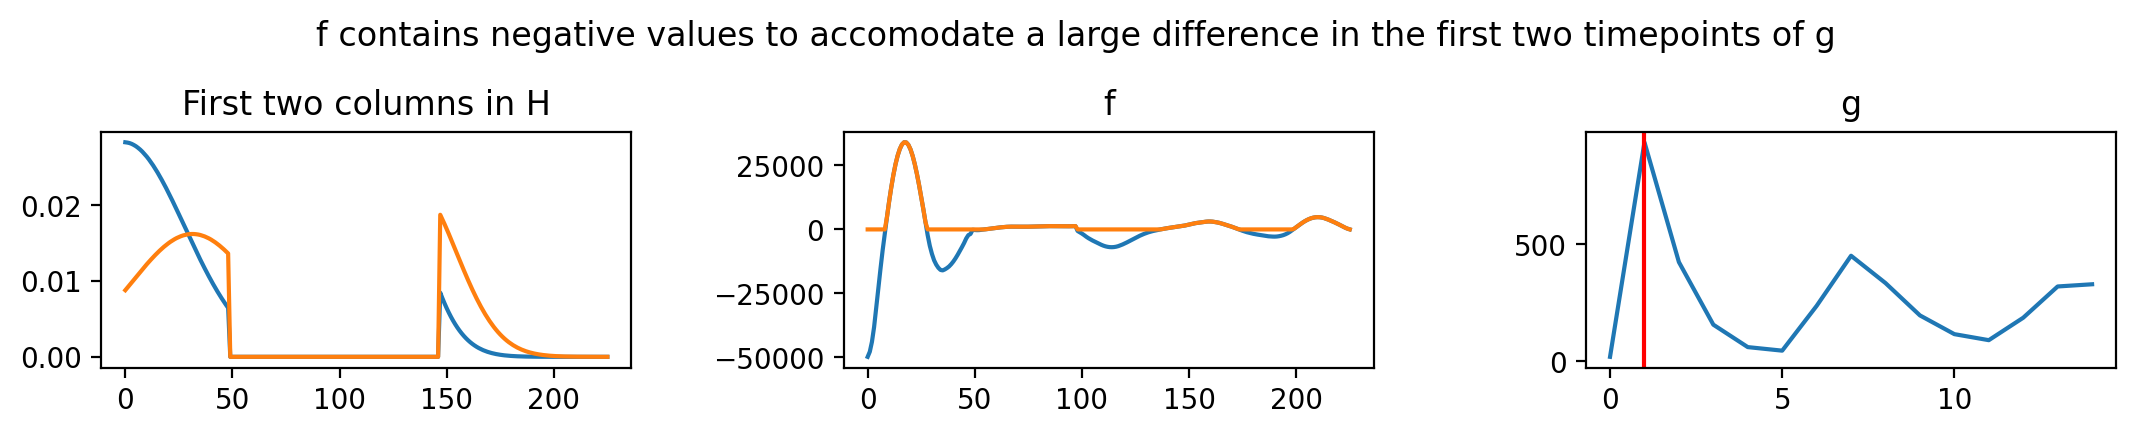

In [317]:
plt.figure(figsize=(13, 2))
plt.subplots_adjust(top=0.7, wspace=0.4)

plt.subplot(1, 3, 1)
plt.plot(model.H[0, :])
plt.plot(model.H[1, :])
plt.title("First two columns in H")

plt.subplot(1, 3, 2)
plt.plot(model.f)
plt.title("f")
plt.plot(f_mod)

plt.subplot(1, 3, 3)
plt.plot(model.g)
plt.title("g")
plt.axvline(1, c='red')

plt.suptitle("f contains negative values to accomodate a large difference"
             " in the first two timepoints of g")

In [313]:
f_mod = model.f.copy()
f_mod[f_mod < 0] = 0

In [314]:
print("First predicted g: ", np.matmul(model.H[0, :], f_mod))

First predicted g:  9781.78257984863


In [302]:
print("First predicted g: ", np.matmul(model.H[0, :], model.f))
print("First predicted g: ", np.matmul(model.H[1, :], model.f))

"""
The difference between the first two rows of H is the sharp decrease in recovery cells for
the first RG1 timepoints.

The model takes advantage of using a very negative number to cancel out what is expected to
be many cells in the first timepoint.

What is interesting is that the model uses negative values rather than small values close
to zero.

---


Here is the mathematical intuition or point I may not be understanding.

Why negative numbers rather than numbers or values close to zero:

    Possibly because it is a linear system of equations.
    
    ** The largely negative values cancels out the large values later in the f matrix (?)

"""

First predicted g:  18.171242128901724
First predicted g:  792.8520254192512
